# 第 21 课：FSA 与 WFST——状态、弧、权重和最短路径

先用几十行 Python 实现最小图搜索。理解结构后，再看 OpenFst/Kaldi 的高性能实现。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 语言模型与 WFST |
| 建议投入 | 3～5 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 20 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | FSA/FST、负对数权重、最短路径 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：FSA/FST、负对数权重、最短路径。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").exists(): return p
    raise FileNotFoundError("请从 learn_asr 或 notebooks 目录启动 Jupyter")

ROOT = find_root()
BLANK = "∅"
plt.rcParams["figure.figsize"] = (11, 4)
print("项目根目录:", ROOT)

from dataclasses import dataclass
import heapq

项目根目录: <REPO_ROOT>


## 1. FSA 与 FST

- FSA/acceptor：一条弧读入一个符号，判断序列是否合法并累计权重。
- FST/transducer：一条弧同时有 input label 和 output label，可完成 token→词、音素→词等映射。
- `ε`：不消耗或不产生普通符号。

In [2]:
@dataclass(frozen=True)
class Arc:
    src:int; dst:int; ilabel:str; olabel:str; cost:float

arcs=[Arc(0,1,"n","你",.2),Arc(1,2,"h","好",.3),Arc(0,3,"n","泥",.8),Arc(3,2,"h","好",.4)]
for a in arcs: print(a)

Arc(src=0, dst=1, ilabel='n', olabel='你', cost=0.2)
Arc(src=1, dst=2, ilabel='h', olabel='好', cost=0.3)
Arc(src=0, dst=3, ilabel='n', olabel='泥', cost=0.8)
Arc(src=3, dst=2, ilabel='h', olabel='好', cost=0.4)


## 2. 权重常用负对数代价

若路径概率相乘，令 `cost=-log(p)` 后，整条路径的 cost 相加；最佳路径就是最短路径。

In [3]:
def shortest_path(arcs,start,final):
    out={}
    for a in arcs: out.setdefault(a.src,[]).append(a)
    q=[(0.0,start,[])];best={start:0.0}
    while q:
        cost,s,path=heapq.heappop(q)
        if s==final:return cost,path
        if cost!=best[s]:continue
        for a in out.get(s,[]):
            nc=cost+a.cost
            if nc<best.get(a.dst,float("inf")):
                best[a.dst]=nc;heapq.heappush(q,(nc,a.dst,path+[a]))
    return float("inf"),[]
cost,path=shortest_path(arcs,0,2)
print("best cost",cost,"output","".join(a.olabel for a in path))

best cost 0.5 output 你好


## 3. 画出 transducer

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27877 (\N{CJK UNIFIED IDEOGRAPH-6CE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


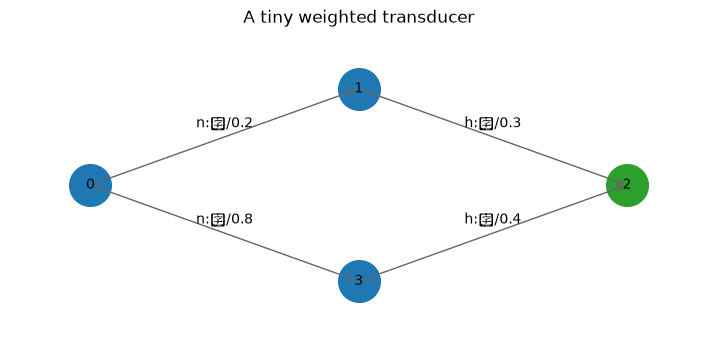

In [4]:
positions={0:(0,0),1:(1,1),3:(1,-1),2:(2,0)}
fig,ax=plt.subplots(figsize=(9,4))
for a in arcs:
    x1,y1=positions[a.src];x2,y2=positions[a.dst]
    ax.annotate("",(x2,y2),(x1,y1),arrowprops=dict(arrowstyle="->",color="0.4"))
    ax.text((x1+x2)/2,(y1+y2)/2+.1,f"{a.ilabel}:{a.olabel}/{a.cost}",ha="center")
for s,(x,y) in positions.items():
    ax.scatter(x,y,s=900,color="C0" if s!=2 else "C2");ax.text(x,y,str(s),ha="center",va="center")
ax.set(xlim=(-.3,2.3),ylim=(-1.6,1.6),title="A tiny weighted transducer");ax.axis("off");plt.show()

## 4. 三个核心优化操作

- composition：把前一个 FST 的输出与后一个 FST 的输入连接；
- determinization：让同一状态对同一输入不再有多条竞争弧；
- minimization：在保持行为等价时减少状态和弧。

它们不是“画图技巧”，而是让大型解码图可运行的关键。

## 本课测试

1. FSA 与 FST 的主要差异是什么？
2. 为什么使用 `-log(probability)`？
3. epsilon 表示普通空格吗？
4. 最短路径对应概率最大还是最小？
5. determinization/minimization 的目标是什么？

<details><summary>展开参考答案</summary>

1. FST 同时定义输入和输出映射。2. 把概率连乘变成代价相加。3. 不是，是不消费/不输出普通符号的空转移。4. 概率最大，因为负对数代价最小。5. 保持等价的同时减少歧义和图规模，提高搜索效率。

</details>

<!-- course-upgrade-v2 -->
## 强化练习：第 21 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `FSA/FST`、`负对数权重`、`最短路径`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**把概率和 cost 的方向写反**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**实现小型 weighted shortest path**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**为 L、G composition 建立标签接口**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：FSA/FST、负对数权重、最短路径。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 FSA/FST、负对数权重、最短路径。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
